# Assignment 1: Simple Linear Regression

1. Read in the "Computers.csv" file & perform any desired EDA.
2. Fit a regression model with target = "price".  Fit your model on the feature with the strongest correlation to price
3. Interpret the model equation
4. Visualize the residuals of your model
5. Make predictions for common values of your feature

In [1]:
import pandas as pd

df_computers = pd.read_csv("../Data/Computers.csv")

df_computers.head()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
0,1499,25,80,4,14,no,no,yes,94,1
1,1795,33,85,2,14,no,no,yes,94,1
2,1595,25,170,4,15,no,no,yes,94,1
3,1849,25,170,8,14,no,no,no,94,1
4,3295,33,340,16,14,no,no,yes,94,1


### EDA

In [2]:
df_computers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6259 entries, 0 to 6258
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   price    6259 non-null   int64 
 1   speed    6259 non-null   int64 
 2   hd       6259 non-null   int64 
 3   ram      6259 non-null   int64 
 4   screen   6259 non-null   int64 
 5   cd       6259 non-null   object
 6   multi    6259 non-null   object
 7   premium  6259 non-null   object
 8   ads      6259 non-null   int64 
 9   trend    6259 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 489.1+ KB


In [3]:
df_computers.cd.value_counts()
df_computers.cd = df_computers.cd.map({'no': 0, 'yes': 1})
df_computers.multi = df_computers.multi.map({'no': 0, 'yes': 1})
df_computers.premium = df_computers.premium.map({'no': 0, 'yes': 1})

In [6]:
df_computers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6259 entries, 0 to 6258
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   price    6259 non-null   int64
 1   speed    6259 non-null   int64
 2   hd       6259 non-null   int64
 3   ram      6259 non-null   int64
 4   screen   6259 non-null   int64
 5   cd       6259 non-null   int64
 6   multi    6259 non-null   int64
 7   premium  6259 non-null   int64
 8   ads      6259 non-null   int64
 9   trend    6259 non-null   int64
dtypes: int64(10)
memory usage: 489.1 KB


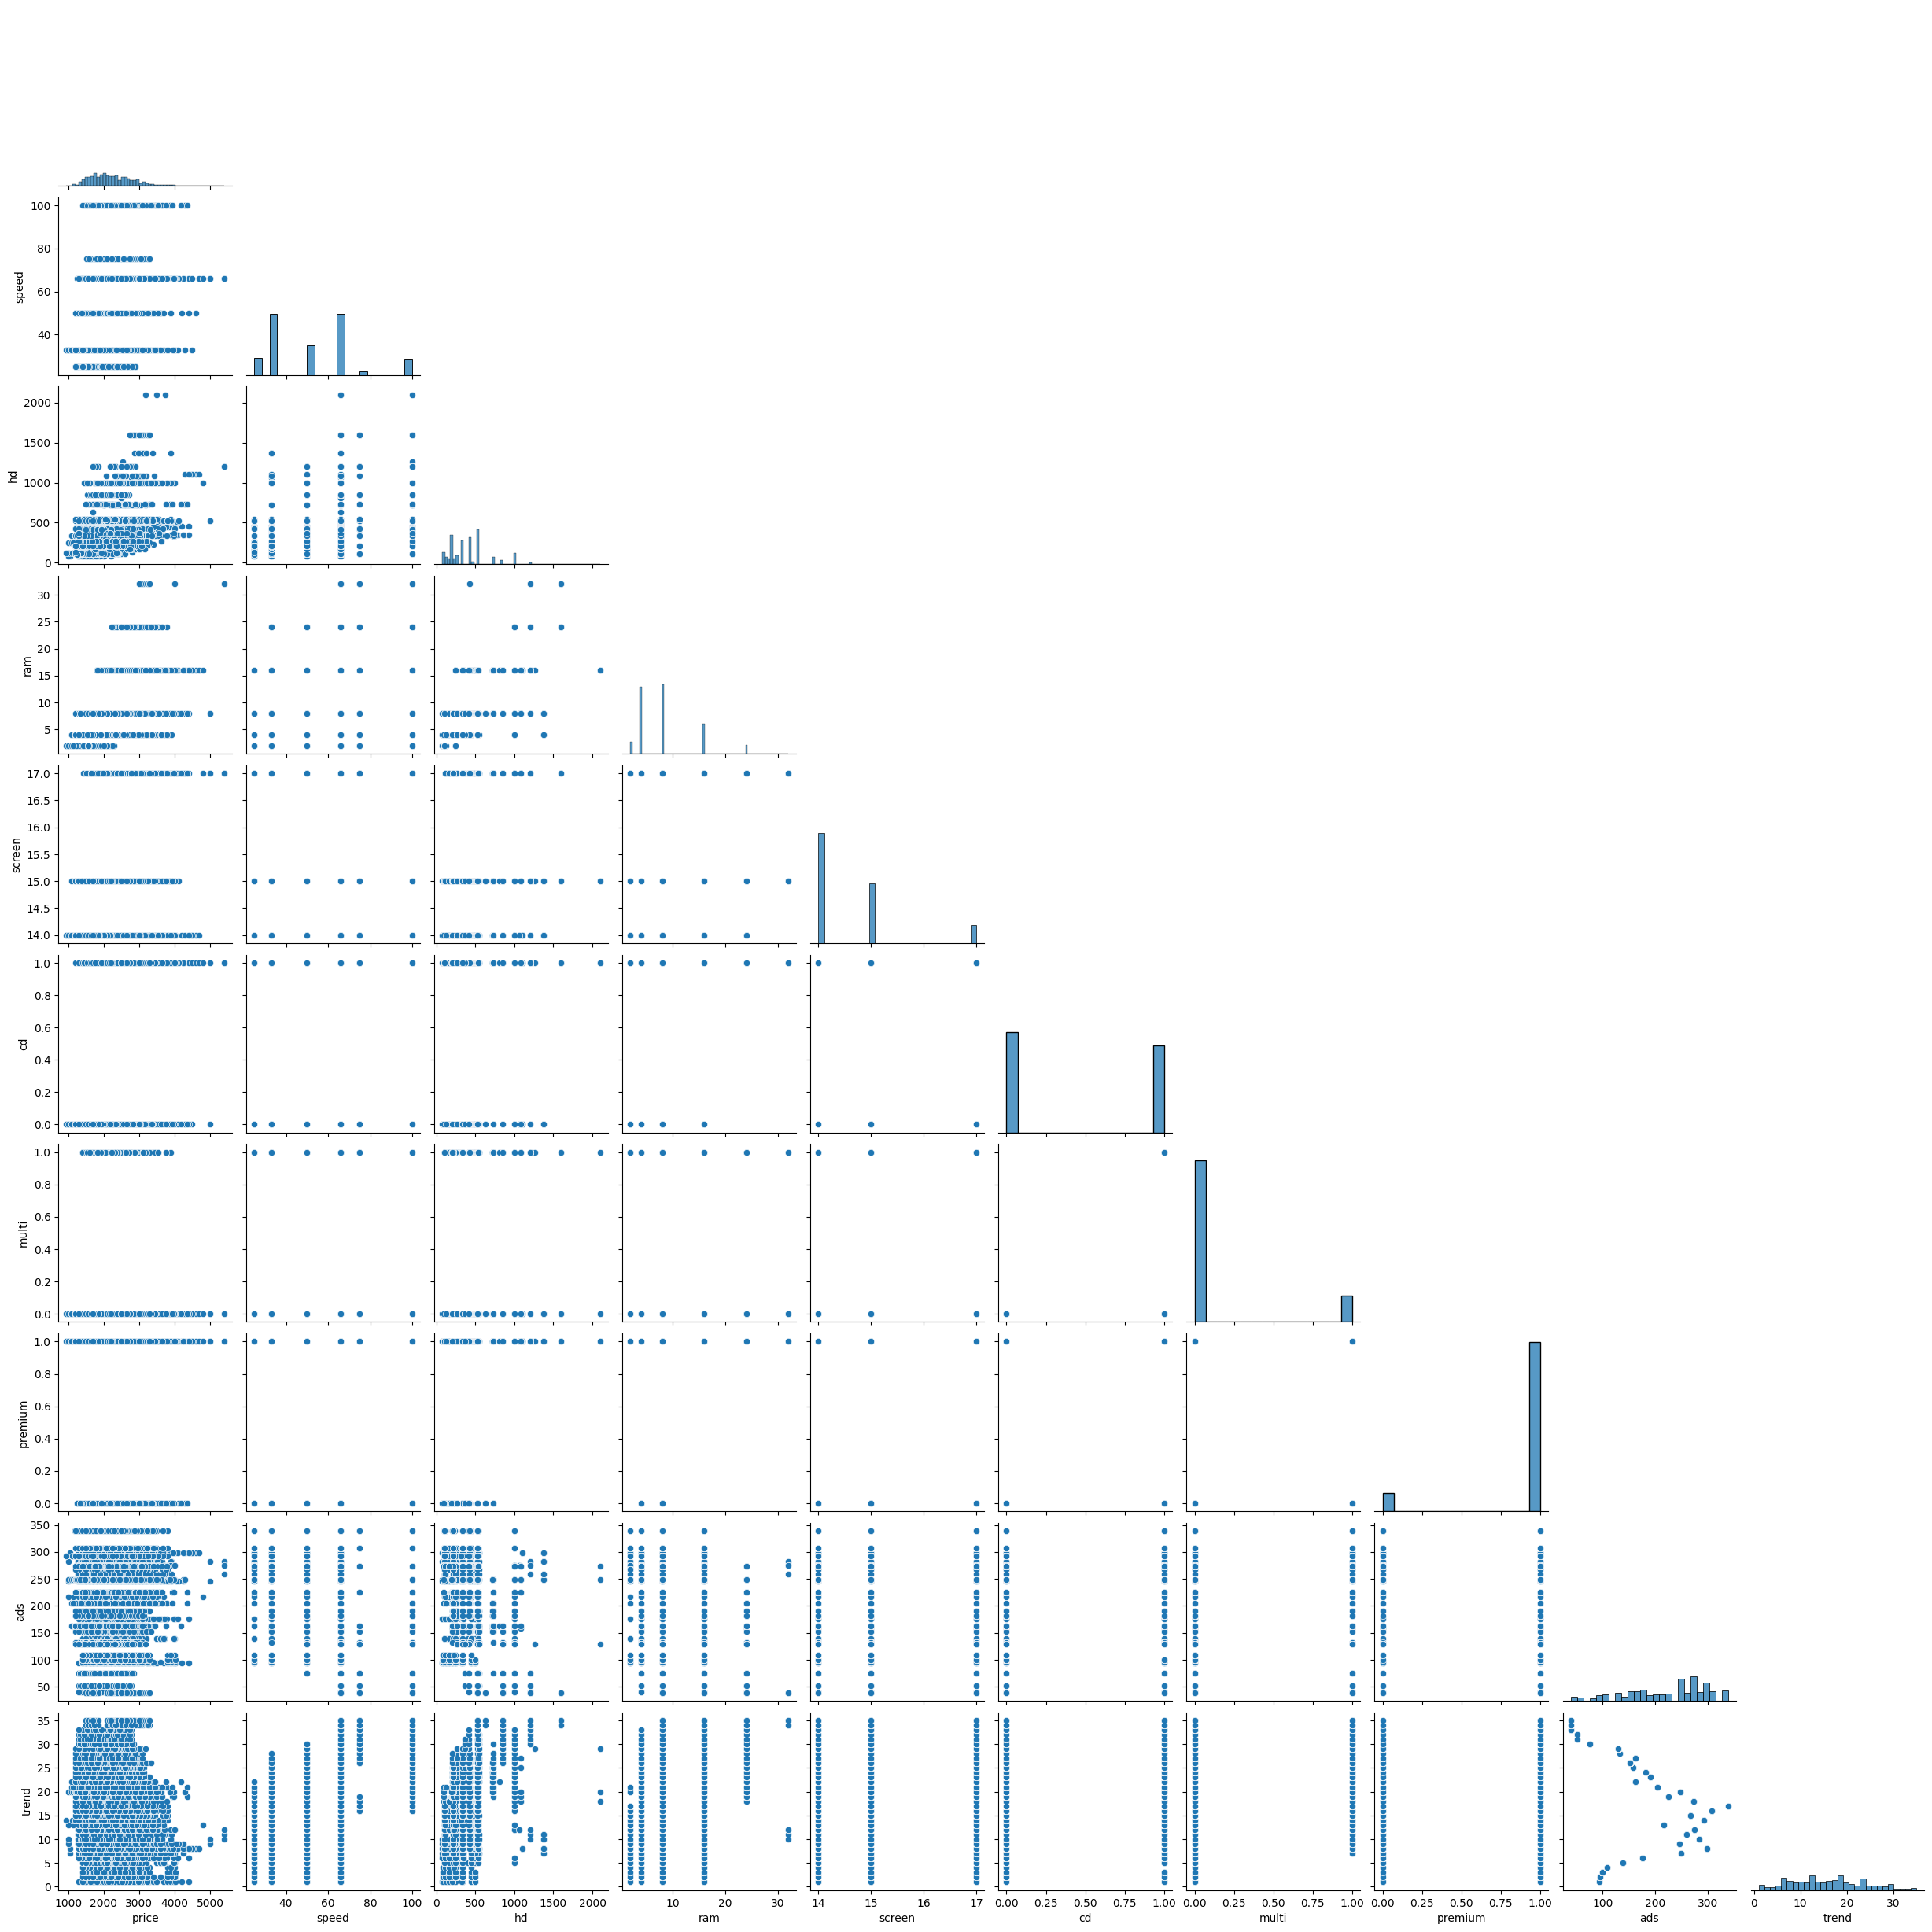

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df_computers, corner=True)

<Axes: xlabel='price', ylabel='Count'>

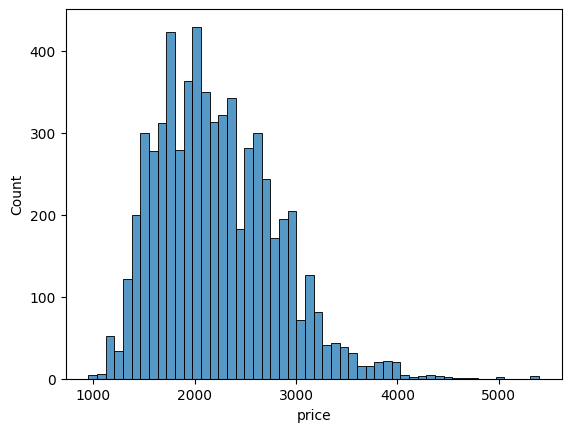

In [9]:
sns.histplot(df_computers['price'])

In [10]:
# 상관관계 분석
df_computers.corr()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
price,1.000000,0.300976,0.430258,0.622748,0.296041,0.197343,-0.016651,-0.080696,0.054540,-0.199987
speed,0.300976,1.000000,0.372304,0.234760,0.189074,0.258260,0.084172,0.114208,-0.215232,0.405438
hd,0.430258,0.372304,1.000000,0.777726,0.232802,0.503570,0.092805,0.196924,-0.323222,0.577790
ram,0.622748,0.234760,0.777726,1.000000,0.208954,0.438504,0.045497,0.197145,-0.181670,0.276844
screen,0.296041,0.189074,0.232802,0.208954,1.000000,0.129488,-0.001740,0.018745,-0.093919,0.188614
cd,0.197343,0.258260,0.503570,0.438504,0.129488,1.000000,0.432179,0.216077,-0.061091,0.445780
multi,-0.016651,0.084172,0.092805,0.045497,-0.001740,0.432179,1.000000,0.124775,-0.030394,0.210907
premium,-0.080696,0.114208,0.196924,0.197145,0.018745,0.216077,0.124775,1.000000,-0.152023,0.042107
ads,0.054540,-0.215232,-0.323222,-0.181670,-0.093919,-0.061091,-0.030394,-0.152023,1.000000,-0.318553
trend,-0.199987,0.405438,0.577790,0.276844,0.188614,0.445780,0.210907,0.042107,-0.318553,1.000000


### Model Fitting

In [11]:
import statsmodels.api as sm

In [12]:
X = sm.add_constant(df_computers["ram"])
y = df_computers["price"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     3964.
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:34:31   Log-Likelihood:                -47180.
No. Observations:                6259   AIC:                         9.436e+04
Df Residuals:                    6257   BIC:                         9.438e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1687.2925     10.221    165.073      0.000    1667.255    1707.330
ram           64.2316      1.020     62.959      0.000      62.232      66.232
==============================================================================
Omnibus:                     1327.783   Durbin-Watson:                   1.533
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3113.140
Skew:                           1.188   Prob(JB):                         0.00
Kurtosis:                       5.508   Cond. No.                         17.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Intepretation:


### Plot Residuals

<Axes: ylabel='None'>

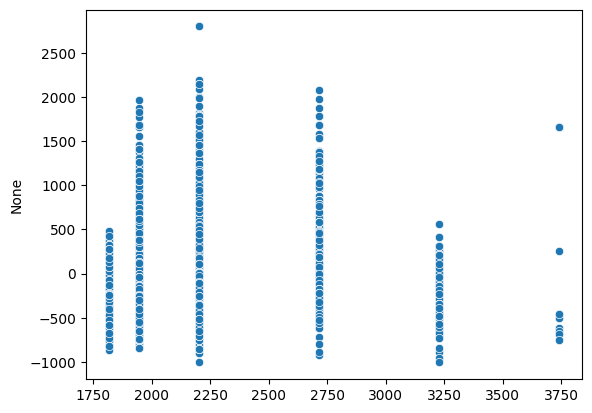

In [13]:
sns.scatterplot(x=model.predict(), y=model.resid)

### Make Predictions with the values below

In [20]:
feature_values = [0, 2, 4, 8, 16, 32, 64]

df_prediction = sm.add_constant(pd.DataFrame({"ram": feature_values}))

In [ ]:
model.predict(df_prediction)

0    1687.292537
1    1815.755790
2    1944.219043
3    2201.145550
4    2714.998564
5    3742.704591
6    5798.116644
dtype: float64